I use DistilBERT because it is smaller, faster, and designed for sequence classification tasks while maintaining performance close to BERT. DistilBERT is commonly used with AutoModelForSequenceClassification, and unlike BERT it does not use token_type_ids.

Required Libraries

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt

Load dataset

In [2]:
dataset = load_dataset("stanfordnlp/imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

load DistilBERT tokenizer

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenize the dataset

In [4]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256
    )

In [5]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Remove raw text column

In [6]:
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

Rename Label Column

In [7]:
tokenized_dataset = tokenized_dataset.rename_column("label","labels")

Data Collator

In [8]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Load DistilBERT Model

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Define Metrics

In [10]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {

        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "precision": precision_score(
            labels,
            predictions
        ),

        "recall": recall_score(
            labels,
            predictions
        ),

        "f1": f1_score(
            labels,
            predictions
        )
    }

Training Arguments

In [11]:
training_args = TrainingArguments(

    output_dir="./distilbert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=2,

    weight_decay=0.01,

    load_best_model_at_end=True,

    report_to="none"
)

Create Trainer

In [13]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_dataset["train"],

    eval_dataset=tokenized_dataset["test"],

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

Train Model

In [14]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.257177,0.247374,0.900840,0.939479,0.856880,0.896280
2,0.163183,0.269488,0.914200,0.904461,0.926240,0.915221


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3126, training_loss=0.22869379003308785, metrics={'train_runtime': 1508.3574, 'train_samples_per_second': 33.149, 'train_steps_per_second': 2.072, 'total_flos': 3311668407975168.0, 'train_loss': 0.22869379003308785, 'epoch': 2.0})

Evaluate model

In [15]:
results = trainer.evaluate()
print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.163183,0.247374,2,0.900840,0.939479,0.856880,0.896280


{'eval_loss': 0.24737408757209778, 'eval_accuracy': 0.90084, 'eval_precision': 0.9394789930707833, 'eval_recall': 0.85688, 'eval_f1': 0.8962804903560521}


Generate Predictions

In [16]:
predictions = trainer.predict(
    tokenized_dataset["test"]
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

Classification Report

In [17]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.87      0.94      0.91     12500
    Positive       0.94      0.86      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



Confusion Matrix

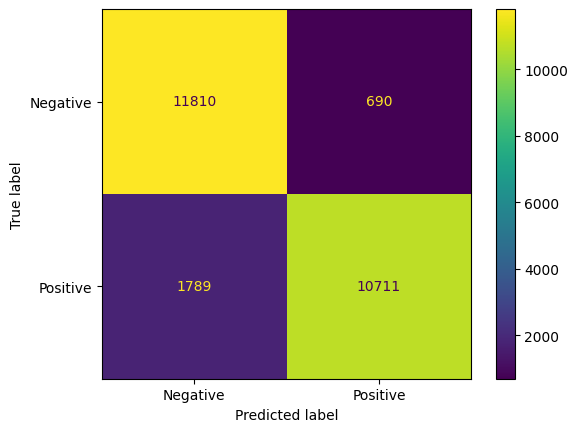

In [18]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot()

plt.show()

Custom Review Testing

In [19]:
reviews = [

    "This movie was absolutely fantastic.",

    "Worst movie I have ever watched.",

    "Amazing acting and excellent story.",

    "The film was boring and too long.",

    "A masterpiece of cinema."
]

In [22]:
for review in reviews:

    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move inputs to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():

        outputs = model(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    label = (
        "Positive"
        if prediction == 1
        else "Negative"
    )

    print(
        f"\nReview: {review}"
    )

    print(
        f"Prediction: {label}"
    )


Review: This movie was absolutely fantastic.
Prediction: Positive

Review: Worst movie I have ever watched.
Prediction: Negative

Review: Amazing acting and excellent story.
Prediction: Positive

Review: The film was boring and too long.
Prediction: Negative

Review: A masterpiece of cinema.
Prediction: Positive


Prediction Functions

In [25]:
def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move inputs to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():

        outputs = model(**inputs)

    probs = F.softmax(
        outputs.logits,
        dim=1
    )

    confidence, prediction = torch.max(
        probs,
        dim=1
    )

    sentiment = (
        "Positive"
        if prediction.item() == 1
        else "Negative"
    )

    return {

        "sentiment": sentiment,

        "confidence": round(
            confidence.item()*100,
            2
        )
    }

In [26]:
predict_sentiment(
    "This movie was brilliant and inspiring."
)

{'sentiment': 'Positive', 'confidence': 99.33}